# NLP-Driven Dynamic Product Feed Optimization

### Case Study

#### Semantic Product–Trend Matching using Sentence Transformers and FAISS

---

### Objective

The goal of this project is to build a semantic matching engine that connects real-time social media trends with products from an e-commerce catalog.

Traditional keyword matching often fails to capture consumer intent because trending phrases and product descriptions may use different vocabulary while referring to similar concepts. To address this challenge, this project leverages transformer-based sentence embeddings and vector similarity search to identify semantically relevant product-trend pairs.

The final output is an optimized product catalog where each product is associated with its most relevant social media trends and an automatically generated optimized product title.

## Table of Contents

1. Project Overview
2. Exploratory Data Analysis
3. Data Preprocessing
4. Embedding Generation
5. Similarity Search with FAISS
6. Trend Matching
7. Product Title Optimization
8. Results
9. Conclusion

In [47]:
!pip install sentence-transformers faiss-cpu pandas numpy scikit-learn

In [48]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
import faiss

In [49]:
trends = pd.read_csv("social_media_trends_large.csv")

products = pd.read_csv("ecommerce_product_catalog_large.csv")

In [50]:
print("Trends Dataset Shape:", trends.shape)

print("Products Dataset Shape:", products.shape)

Trends Dataset Shape: (25000, 5)
Products Dataset Shape: (20943, 5)


In [51]:
print("TRENDS DATASET")
trends.info()

TRENDS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   trend_id             25000 non-null  object
 1   trend_keyword        25000 non-null  object
 2   platform_source      25000 non-null  object
 3   search_volume_score  25000 non-null  int64 
 4   trend_category       25000 non-null  object
dtypes: int64(1), object(4)
memory usage: 976.7+ KB


In [52]:
print("PRODUCTS DATASET")
products.info()

PRODUCTS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20943 entries, 0 to 20942
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           20943 non-null  object 
 1   product_title        20943 non-null  object 
 2   product_description  20943 non-null  object 
 3   category             20942 non-null  object 
 4   price_inr            20942 non-null  float64
dtypes: float64(1), object(4)
memory usage: 818.2+ KB


In [53]:
trends.head()

,trend_id,trend_keyword,platform_source,search_volume_score,trend_category
0,T000001,luxury gaming setup guide,Instagram,389961,Electronics
1,T000002,sustainable gift ideas review,Pinterest,202671,Kitchen
2,T000003,smart skincare routine unboxing,TikTok,423478,Beauty
3,T000004,Y2K desk setup review,TikTok,365216,Kitchen
4,T000005,top rated desk setup review,Pinterest,464632,Home Decor


In [54]:
products.head()

,product_id,product_title,product_description,category,price_inr
0,P000001,Smart Chair Waterproof,Experience premium quality with our top-rated ...,Kitchen,8419.52
1,P000002,Durable Camera Bundle,Designed for everyday use. Built to last and w...,Beauty,5821.62
2,P000003,Ergonomic Speaker 2026 Edition,A must-have for enthusiasts. Features state-of...,Sports & Outdoors,50475.62
3,P000004,Vintage Monitor with RGB,Upgrade your lifestyle with this. Built to las...,Kitchen,80215.35
4,P000005,Pro Headphones Bundle,Experience premium quality with our top-rated ...,Home Decor,42137.44


In [55]:
print("Missing Values in Trends Dataset")
print(trends.isnull().sum())

Missing Values in Trends Dataset
trend_id               0
trend_keyword          0
platform_source        0
search_volume_score    0
trend_category         0
dtype: int64


In [56]:
print("\nMissing Values in Products Dataset")
print(products.isnull().sum())


Missing Values in Products Dataset
product_id             0
product_title          0
product_description    0
category               1
price_inr              1
dtype: int64


In [57]:
print("Duplicate Trend Rows:",
      trends.duplicated().sum())

print("Duplicate Product Rows:",
      products.duplicated().sum())

Duplicate Trend Rows: 0
Duplicate Product Rows: 0


# Exploratory Data Analysis (EDA)

The purpose of EDA is to understand the structure, quality, and characteristics of both datasets before applying NLP techniques.

The analysis includes:

- Dataset dimensions
- Missing value analysis
- Duplicate record analysis
- Trend distribution across platforms
- Product category distribution
- Search volume analysis
- Product pricing analysis
- Text length analysis

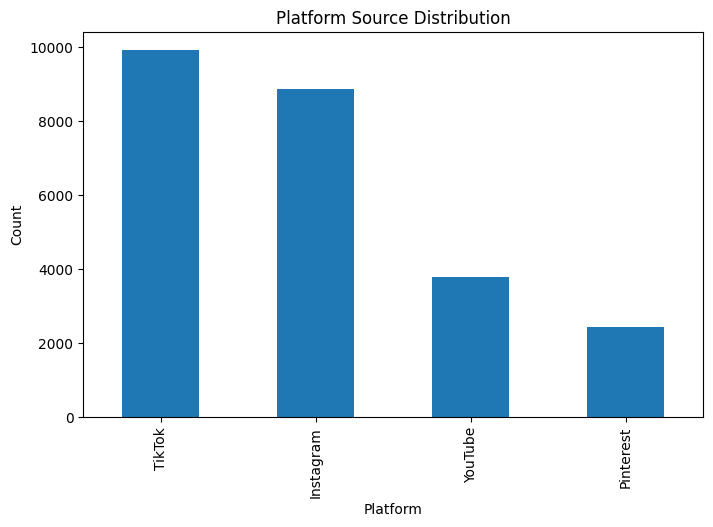

In [58]:
trends["platform_source"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Platform Source Distribution")
plt.xlabel("Platform")
plt.ylabel("Count")

plt.show()

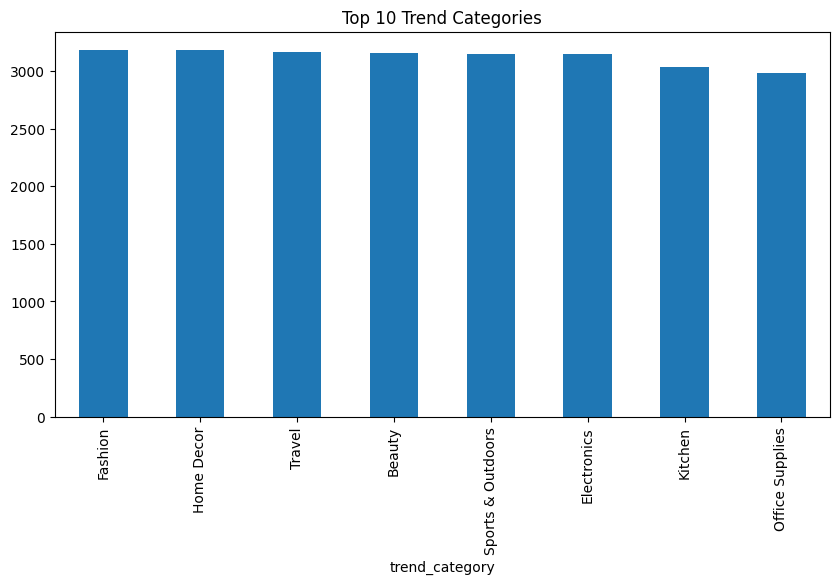

In [59]:
trends["trend_category"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Trend Categories")

plt.show()

In [60]:
trends["search_volume_score"].describe()

,search_volume_score
count,25000.00000
mean,249221.20312
std,144404.74291
min,1008.00000
25%,124166.75000
50%,248153.00000
75%,375075.25000
max,499951.00000


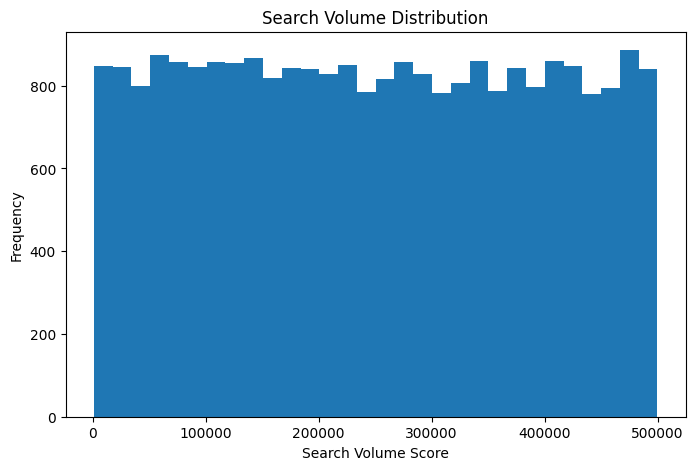

In [61]:
plt.figure(figsize=(8,5))

plt.hist(
    trends["search_volume_score"],
    bins=30
)

plt.title("Search Volume Distribution")
plt.xlabel("Search Volume Score")
plt.ylabel("Frequency")

plt.show()

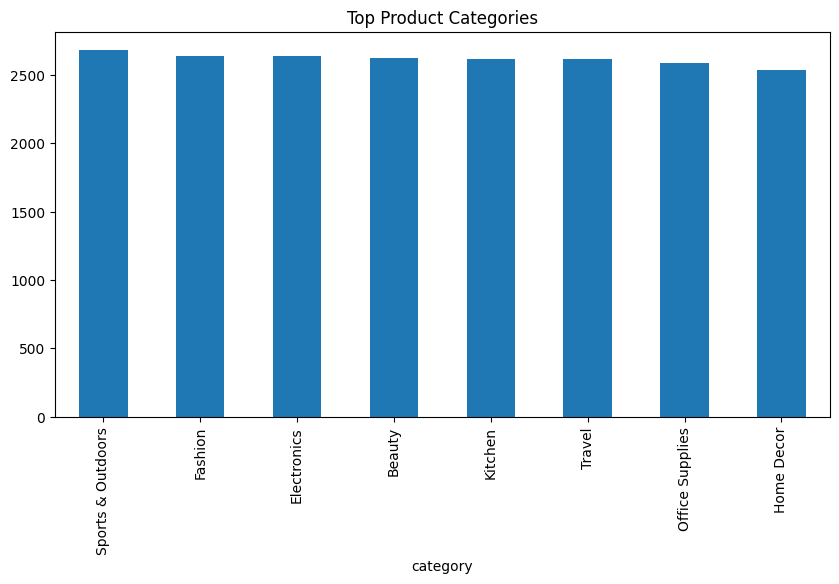

In [62]:
products["category"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Product Categories")

plt.show()

In [63]:
products["price_inr"].describe()

,price_inr
count,20942.000000
mean,41673.629405
std,23668.538796
min,830.000000
25%,21104.617500
50%,41632.800000
75%,62157.455000
max,82996.680000


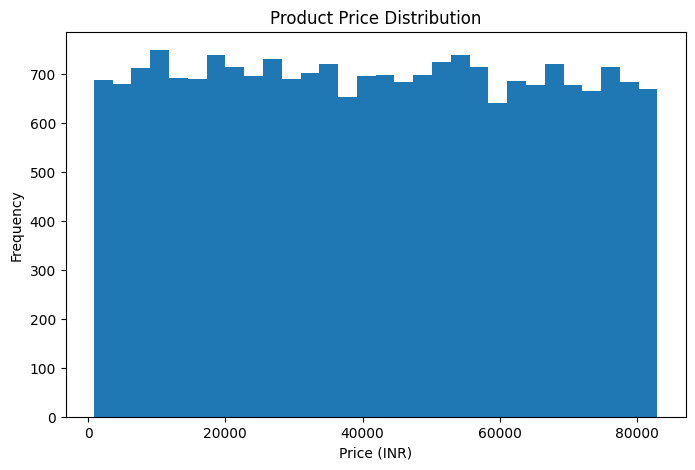

In [64]:
plt.figure(figsize=(8,5))

plt.hist(
    products["price_inr"],
    bins=30
)

plt.title("Product Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")

plt.show()

In [65]:
trends["trend_keyword"] = trends["trend_keyword"].fillna("")

products["product_description"] = products["product_description"].fillna("")

products["product_title"] = products["product_title"].fillna("")

In [66]:
products["description_length"] = products[
    "product_description"
].apply(len)

products["description_length"].describe()

,description_length
count,20943.000000
mean,97.798548
std,11.313981
min,37.000000
25%,89.000000
50%,95.000000
75%,105.000000
max,125.000000


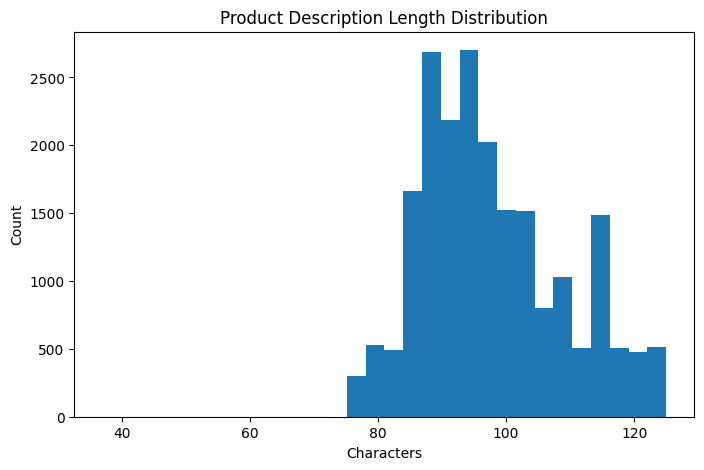

In [67]:
plt.figure(figsize=(8,5))

plt.hist(
    products["description_length"],
    bins=30
)

plt.title("Product Description Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()

In [68]:
trends["keyword_length"] = trends[
    "trend_keyword"
].apply(len)

trends["keyword_length"].describe()

,keyword_length
count,25000.00000
mean,26.55016
std,3.97566
min,17.00000
25%,23.00000
50%,26.00000
75%,29.00000
max,40.00000


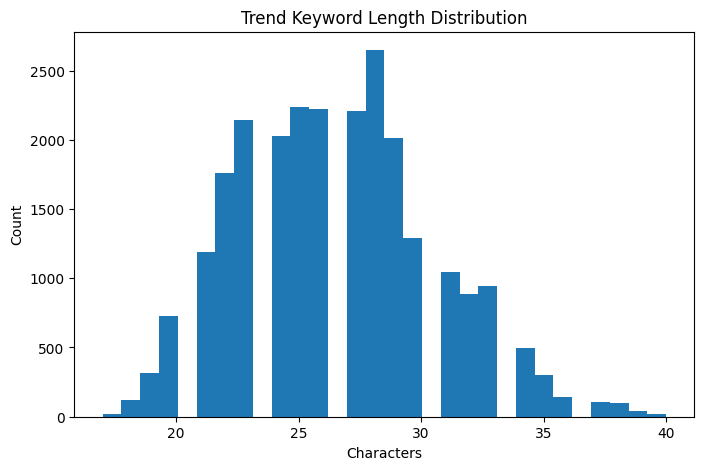

In [69]:
plt.figure(figsize=(8,5))

plt.hist(
    trends["keyword_length"],
    bins=30
)

plt.title("Trend Keyword Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")

plt.show()

# Data Preprocessing

Before generating embeddings, textual data must be cleaned and standardized.

The preprocessing steps include:

- Handling missing values
- Converting text to lowercase
- Removing special characters
- Removing unnecessary spaces
- Combining product titles and descriptions to create richer semantic representations

In [70]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        '',
        text
    )

    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

In [71]:
trends["clean_trend"] = trends[
    "trend_keyword"
].apply(clean_text)

products["clean_description"] = products[
    "product_description"
].apply(clean_text)

In [72]:
products["combined_text"] = (
    products["product_title"] + " " +
    products["product_description"]
)

products["combined_text"] = products[
    "combined_text"
].apply(clean_text)

# Semantic Embedding Generation

To capture the semantic meaning of trends and product information, a pre-trained Sentence Transformer model is used.

Model Selected:
- all-MiniLM-L6-v2

This model converts text into dense numerical vectors (embeddings) that preserve semantic relationships between phrases and sentences.

In [75]:
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [76]:
trend_embeddings = model.encode(
    trends["clean_trend"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/391 [00:00<?, ?it/s]

In [77]:
product_embeddings = model.encode(
    products["combined_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/328 [00:00<?, ?it/s]

In [78]:
print("Trend Embeddings Shape:")
print(trend_embeddings.shape)

print("\nProduct Embeddings Shape:")
print(product_embeddings.shape)

Trend Embeddings Shape:
(25000, 384)

Product Embeddings Shape:
(20943, 384)


# Similarity Search using FAISS

Computing similarity between every trend and every product would require approximately:

25,000 × 50,000 = 1.25 Billion comparisons

To improve efficiency, Facebook AI Similarity Search (FAISS) is used.

FAISS enables fast nearest-neighbor retrieval without generating the complete similarity matrix in memory.

In [79]:
faiss.normalize_L2(
    trend_embeddings
)

faiss.normalize_L2(
    product_embeddings
)

In [80]:
dimension = trend_embeddings.shape[1]

index = faiss.IndexFlatIP(
    dimension
)

index.add(
    trend_embeddings
)

print("Index Created Successfully")

Index Created Successfully


In [81]:
k = 3

similarity_scores, trend_indices = index.search(
    product_embeddings,
    k
)

# Trend Matching and Retrieval

For each product embedding, the FAISS index is queried to retrieve the Top-3 most semantically similar social media trends.

Cosine similarity is used as the similarity metric after embedding normalization.

In [82]:
product_number = 0

print(
    products.iloc[product_number]
    ["product_description"]
)

print("\nTop Matches:\n")

for idx, score in zip(
    trend_indices[product_number],
    similarity_scores[product_number]
):

    print(
        trends.iloc[idx]["trend_keyword"],
        round(float(score),4)
    )

Experience premium quality with our top-rated product. Features state-of-the-art materials. Order now while supplies last!

Top Matches:

smart streetwear review 0.3563
smart streetwear review 0.3563
smart streetwear review 0.3563


In [83]:
top_trend_1 = []
top_trend_2 = []
top_trend_3 = []

score_1 = []
score_2 = []
score_3 = []

In [84]:
for i in range(len(products)):

    idx1 = trend_indices[i][0]
    idx2 = trend_indices[i][1]
    idx3 = trend_indices[i][2]

    top_trend_1.append(
        trends.iloc[idx1]["trend_keyword"]
    )

    top_trend_2.append(
        trends.iloc[idx2]["trend_keyword"]
    )

    top_trend_3.append(
        trends.iloc[idx3]["trend_keyword"]
    )

    score_1.append(
        float(similarity_scores[i][0])
    )

    score_2.append(
        float(similarity_scores[i][1])
    )

    score_3.append(
        float(similarity_scores[i][2])
    )

In [85]:
products["top_trend_1"] = top_trend_1
products["top_trend_2"] = top_trend_2
products["top_trend_3"] = top_trend_3

products["similarity_score_1"] = score_1
products["similarity_score_2"] = score_2
products["similarity_score_3"] = score_3

In [86]:
SIMILARITY_THRESHOLD = 0.50

products["top_trend_1"] = np.where(
    products["similarity_score_1"] >= SIMILARITY_THRESHOLD,
    products["top_trend_1"],
    "No Strong Match"
)

# Dynamic Product Title Optimization

After identifying the most relevant trend for each product, an optimized product title is generated.

The objective is to naturally incorporate trending keywords into product titles, improving discoverability, relevance, and potential advertising performance.

In [87]:
optimized_titles = []

for _, row in products.iterrows():

    trend = row["top_trend_1"]

    title = row["product_title"]

    if trend != "No Strong Match":

        optimized_title = (
            f"{trend} Inspired {title}"
        )

    else:

        optimized_title = title

    optimized_titles.append(
        optimized_title
    )

In [88]:
products[
    "optimized_product_title"
] = optimized_titles

In [89]:
products[
    [
        "product_title",
        "top_trend_1",
        "similarity_score_1",
        "optimized_product_title"
    ]
].head(10)

,product_title,top_trend_1,similarity_score_1,optimized_product_title
0,Smart Chair Waterproof,No Strong Match,0.356294,Smart Chair Waterproof
1,Durable Camera Bundle,No Strong Match,0.421510,Durable Camera Bundle
2,Ergonomic Speaker 2026 Edition,No Strong Match,0.462881,Ergonomic Speaker 2026 Edition
3,Vintage Monitor with RGB,No Strong Match,0.368070,Vintage Monitor with RGB
4,Pro Headphones Bundle,No Strong Match,0.279176,Pro Headphones Bundle
5,Minimalist Sunglasses Modern,minimalist streetwear essentials,0.504952,minimalist streetwear essentials Inspired Mini...
6,Pro Wallet Bundle,No Strong Match,0.323055,Pro Wallet Bundle
7,Modern Camera V2,No Strong Match,0.411607,Modern Camera V2
8,Durable Chair Edition,No Strong Match,0.361295,Durable Chair Edition
9,Modern Lamp Set,No Strong Match,0.421086,Modern Lamp Set


# Final Output Generation

The enriched product catalog now contains:

- Top 3 matching trends
- Similarity scores
- Optimized product titles

The final dataset is exported as a CSV file for further business use and deployment.

In [90]:
products.to_csv(
    "optimized_catalog.csv",
    index=False
)

from google.colab import files

files.download("optimized_catalog.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project successfully demonstrates the application of Natural Language Processing (NLP) and vector similarity search for dynamic product feed optimization.

Key achievements:

- Preprocessed and analyzed large-scale trend and product datasets.
- Generated semantic embeddings using Sentence Transformers.
- Built an efficient similarity search engine using FAISS.
- Identified the Top-3 relevant trends for each product.
- Generated optimized product titles based on trend relevance.

By leveraging semantic matching instead of traditional keyword matching, the solution better captures consumer intent and enables more effective alignment between social demand and product inventory.